# Market Creator Activity Dashboard

**Objective:** Monitor and analyze market creator activity on Gnosis Chain.

## How to run

1. Ensure you have the root `.env` file with `GNOSIS_RPC` set.
2. Install dependencies: `poetry install` from the repo root.
3. Run all cells top-to-bottom.

In [1]:
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Allow imports from repo root
sys.path.insert(0, os.path.abspath(".."))

from market_creator_info import NATIVE_TOKEN, WXDAI_ADDRESS, MarketCreatorConfig, get_all_creators_info
from omen_markets import MarketState

# Canonical icons for each market state — use these everywhere in the notebook
MARKET_STATE_ICONS = {
    MarketState.OPEN: "\U0001f4e5",          # 📥 inbox tray
    MarketState.PENDING: "\U0001f4cb",       # 📋 clipboard
    MarketState.FINALIZING: "\u23f3",        # ⏳ hourglass
    MarketState.ARBITRATING: "\u2696\ufe0f", # ⚖️ balance scale
    MarketState.CLOSED: "\U0001f512",        # 🔒 lock
    MarketState.UNKNOWN: "\u2753",           # ❓ question mark
}


def pct(num, den, fallback="\u2014"):
    """Format num/den as a percentage string, or return fallback if den is 0."""
    return f"{num/den*100:.1f}%" if den else fallback

## Configuration

Define market creators here. Each entry maps a label to a config dict.

Thresholds are per-token-address for `safe` and `owner` separately.
Use `NATIVE_TOKEN` (zero address) for native xDAI, or any ERC-20 contract address.

In [2]:
TOKEN_LABELS = {
    NATIVE_TOKEN: "xDAI",
    WXDAI_ADDRESS: "wxDAI",
}

MARKET_CREATORS: dict[str, MarketCreatorConfig] = {
    "qs": {
        "name": "QS Market Creator",
        "safe_contract_address": "0x89c5cc945dd550BcFfb72Fe42BfF002429F46Fec",
        "markets_to_approve_per_day": 15,
        "thresholds": {
            "safe": {
                NATIVE_TOKEN: 1.0,
                WXDAI_ADDRESS: 50.0,
            },
            "owner": {
                NATIVE_TOKEN: 0.5,
                WXDAI_ADDRESS: 0,
            },
        },
    },
    "pearl": {
        "name": "Pearl Market Creator",
        "safe_contract_address": "0xFfc8029154ECD55ABED15BD428bA596E7D23f557",
        "markets_to_approve_per_day": 8,
        "thresholds": {
            "safe": {
                NATIVE_TOKEN: 1.0,
                WXDAI_ADDRESS: 50.0,
            },
            "owner": {
                NATIVE_TOKEN: 0.5,
                WXDAI_ADDRESS: 0,
            },
        },
    },
}

## Balances

Fetch xDAI and wxDAI balances for each market creator's Safe and owner/signer addresses.
A red circle indicates a balance below the configured threshold.

In [3]:
creators = get_all_creators_info(MARKET_CREATORS)

# Build a lookup from name -> config for threshold access
_cfg_by_name = {cfg["name"]: cfg for cfg in MARKET_CREATORS.values()}

def _alert(value: float, threshold: float) -> str:
    """Return a red dot if below threshold, green dot if OK (skip if threshold is 0)."""
    icon = "\U0001f534" if (threshold > 0 and value < threshold) else "\U0001f7e2"
    return f"{value:.4f} {icon}"

rows = []
for c in creators:
    cfg = _cfg_by_name[c.label]
    safe_thresholds = cfg["thresholds"]["safe"]
    owner_thresholds = cfg["thresholds"]["owner"]

    # Safe row
    row = {
        "Label": c.label,
        "Type": "Safe",
        "Address": c.safe_contract_address,
        "Sig. Threshold": f"{c.threshold}/{len(c.owners)}",
    }
    for token_addr, threshold in safe_thresholds.items():
        label = TOKEN_LABELS.get(token_addr, token_addr[:10])
        balance = c.balances[c.safe_contract_address].get(token_addr, 0)
        row[label] = _alert(balance, threshold)
    rows.append(row)

    # Owner rows
    for owner in c.owners:
        row = {
            "Label": c.label,
            "Type": "Owner/Signer",
            "Address": owner,
            "Sig. Threshold": "",
        }
        for token_addr, threshold in owner_thresholds.items():
            label = TOKEN_LABELS.get(token_addr, token_addr[:10])
            balance = c.balances[owner].get(token_addr, 0)
            row[label] = _alert(balance, threshold)
        rows.append(row)

df_balances = pd.DataFrame(rows)

# Right-align balance columns so the status dots line up
balance_cols = list(TOKEN_LABELS.values())
col_styles = [
    {"selector": f"td.col{df_balances.columns.get_loc(col)}", "props": "text-align: right;"}
    for col in balance_cols if col in df_balances.columns
]
display(HTML(df_balances.style.set_table_styles(col_styles).hide(axis="index").to_html()))

Label,Type,Address,Sig. Threshold,xDAI,wxDAI
QS Market Creator,Safe,0x89c5cc945dd550bcffb72fe42bff002429f46fec,1/1,2.7660 🟢,180.3535 🟢
QS Market Creator,Owner/Signer,0x1cac05cf0bb39945bb0c6446a36b3fd8e26be285,,2.1905 🟢,0.0000 🟢
Pearl Market Creator,Safe,0xffc8029154ecd55abed15bd428ba596e7d23f557,1/1,2.8730 🟢,29.5233 🔴
Pearl Market Creator,Owner/Signer,0xebff9a4079292adddc3d639cf39bfe7f9e4740ab,,9.9668 🟢,0.0000 🟢


## Markets

Fetch all markets from the Omen subgraph and display:
1. Current state breakdown (open, pending, finalizing, arbitrating, closed)
2. Daily history of markets opened, closed (answered), and resolved (finalized) over the last N days

In [4]:
from omen_markets import get_fpmms, markets_to_dataframe
from fpmm_audits import load_audits_df

# Fetch and flatten all markets into a single dict, tagging each with its creator
all_markets = {}
for key, cfg in MARKET_CREATORS.items():
    for m in get_fpmms(cfg["safe_contract_address"])["fixedProductMarketMakers"].values():
        m["_creator"] = key
        all_markets[m["id"]] = m

Fetching fpmms for creator 0x89c5cc945dd550BcFfb72Fe42BfF002429F46Fec...
Fetching fpmms for creator 0xFfc8029154ECD55ABED15BD428bA596E7D23f557...


In [5]:

# Build markets DataFrame
df_markets = markets_to_dataframe(all_markets)
df_markets["creator"] = df_markets["market_id"].map(lambda mid: all_markets[mid]["_creator"])
df_markets["creator_name"] = df_markets["creator"].map(lambda k: MARKET_CREATORS[k]["name"])

# Merge audit summary columns (n_audits, n_valid_audits, n_matching_audits)
df_markets = df_markets.merge(load_audits_df(all_markets), on="market_id", how="left")
_audit_cols = {"n_audits": 0, "n_valid_audits": 0, "n_matching_audits": 0}
df_markets = df_markets.fillna(_audit_cols).astype({c: int for c in _audit_cols})

print(f"df_markets: {len(df_markets)} rows, columns: {list(df_markets.columns)}")
df_markets.tail(2)

df_markets: 15119 rows, columns: ['market_id', 'question_id', 'title', 'outcomes', 'creation_ts', 'opening_ts', 'resolution_ts', 'finalized_ts', 'state', 'current_answer', 'current_answer_hex', 'is_invalid', 'n_answers', 'first_answer_hex', 'is_challenged', 'is_flipped', 'n_challenges', 'current_answer_bond', 'collateral_volume', 'creator', 'creator_name', 'n_audits', 'n_valid_audits', 'n_matching_audits']


,market_id,question_id,title,outcomes,creation_ts,opening_ts,resolution_ts,finalized_ts,state,current_answer,...,is_challenged,is_flipped,n_challenges,current_answer_bond,collateral_volume,creator,creator_name,n_audits,n_valid_audits,n_matching_audits
15117,0x8ac25e0900a3d6d213b533da57d5d6b5408abd0e,0xb7794a2e5274bc7ff5f9e2baae75743ca982814d557d...,"Will the Chinese government publicly announce,...","[Yes, No]",2026-03-15 02:02:05+00:00,2026-03-20 00:00:00+00:00,NaT,NaT,Open,N/A,...,False,False,0,0,19.572023,pearl,Pearl Market Creator,0,0,0
15118,0xa02edb0656d3d87579d3582571331307be3f164f,0x02e6c51d6f544526020c4279b95f353fb3d41ad56a6b...,Will a U.S. federal court grant final approval...,"[Yes, No]",2026-03-15 02:14:55+00:00,2026-03-20 00:00:00+00:00,NaT,NaT,Open,N/A,...,False,False,0,0,8.375000,pearl,Pearl Market Creator,0,0,0


### Markets by state

In [6]:
# Build state summary from df_markets
df_states = df_markets.pivot_table(
    index="creator_name", columns="state", values="market_id", aggfunc="count", fill_value=0,
)
df_states.index.name = "Creator"
df_states.columns.name = None

# Ensure all states appear in order
state_order = list(MarketState)
for s in state_order:
    if s not in df_states.columns:
        df_states[s] = 0
df_states = df_states[state_order]
df_states["Total"] = df_states.sum(axis=1)

display(HTML(df_states.to_html()))

,Open,Pending,Finalizing,Arbitrating,Closed,Unknown,Total
Creator,,,,,,,
Pearl Market Creator,40,3,12,0,2477,0,2532
QS Market Creator,75,14,14,0,12483,1,12587


### Open/closed markets daily history

In [7]:
from datetime import datetime, timedelta, timezone

# Number of recent days for which statistics are displayed (activity, answer distribution, mech results)
STATS_PERIOD_DAYS = 14

now_utc = datetime.now(timezone.utc)
period_start = (now_utc - timedelta(days=STATS_PERIOD_DAYS - 1)).replace(hour=0, minute=0, second=0)
period_end = now_utc

display(HTML(
    f"<b>Study period:</b> {period_start.strftime('%Y-%m-%d %H:%M UTC')} — "
    f"{period_end.strftime('%Y-%m-%d %H:%M UTC')} ({STATS_PERIOD_DAYS} days)"
))

# Build daily activity from df_markets
_df = df_markets[["creator_name", "creation_ts", "finalized_ts"]].copy()
_df["creation_date"] = _df["creation_ts"].dt.date
_df["finalized_date"] = _df["finalized_ts"].dt.date
# "responded" = market received an answer (finalized_ts is set, regardless of whether it's in the past)
# We approximate this with finalized_ts since answer leads to finalization

_dates = [period_end.date() - timedelta(days=i) for i in range(STATS_PERIOD_DAYS - 1, -1, -1)]

for key, cfg in MARKET_CREATORS.items():
    name = cfg["name"]
    expected = cfg.get("markets_to_approve_per_day", "?")
    creator_df = _df[_df["creator_name"] == name]

    opened_counts = creator_df["creation_date"].value_counts()
    closed_counts = creator_df.loc[
        creator_df["finalized_ts"] <= now_utc, "finalized_date"
    ].value_counts()

    rows = []
    for d in reversed(_dates):
        n_open = int(opened_counts.get(d, 0))
        n_closed = int(closed_counts.get(d, 0))
        open_icon = "\U0001f7e2" if n_open == expected else "\U0001f534"
        rows.append({
            "Date": d,
            f"{MARKET_STATE_ICONS[MarketState.OPEN]} Open": f"{n_open} {open_icon}",
            f"{MARKET_STATE_ICONS[MarketState.CLOSED]} Closed": n_closed,
        })

    display(HTML(f"<h4>{name} (expected open/day: {expected})</h4>"))
    display(HTML(pd.DataFrame(rows).to_html(escape=False, index=False)))

Date,📥 Open,🔒 Closed
2026-03-15,15 🟢,15
2026-03-14,15 🟢,8
2026-03-13,15 🟢,14
2026-03-12,15 🟢,13
2026-03-11,15 🟢,22
2026-03-10,15 🟢,18
2026-03-09,15 🟢,15
2026-03-08,15 🟢,13
2026-03-07,15 🟢,8
2026-03-06,15 🟢,16


Date,📥 Open,🔒 Closed
2026-03-15,8 🟢,4
2026-03-14,8 🟢,9
2026-03-13,8 🟢,7
2026-03-12,8 🟢,7
2026-03-11,8 🟢,6
2026-03-10,8 🟢,11
2026-03-09,8 🟢,9
2026-03-08,8 🟢,4
2026-03-07,8 🟢,4
2026-03-06,8 🟢,8


### Closed markets answer analysis

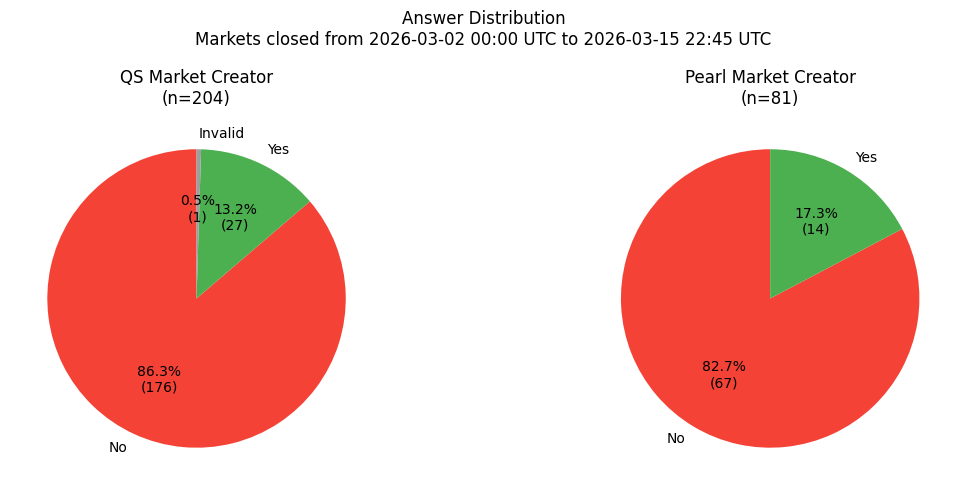

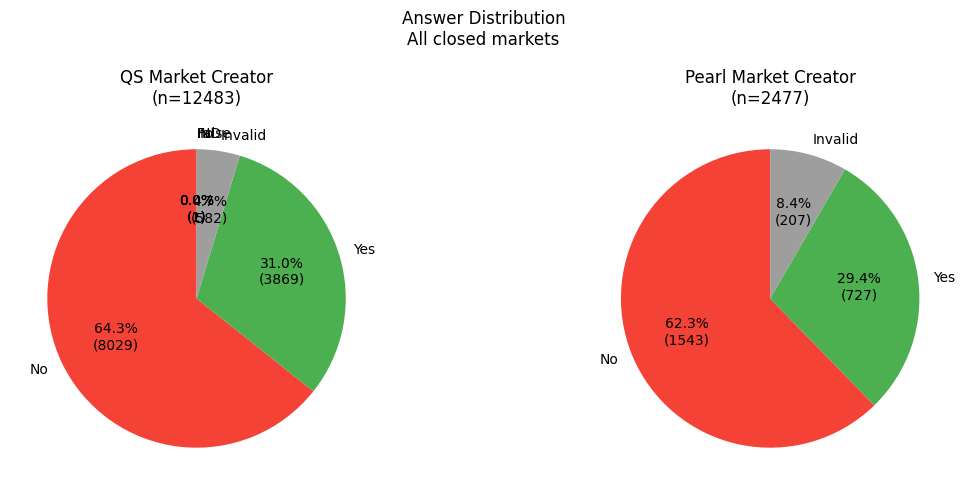

In [8]:
_period_label = (
    f"from {period_start.strftime('%Y-%m-%d %H:%M UTC')} "
    f"to {period_end.strftime('%Y-%m-%d %H:%M UTC')}"
)
_closed_period = f"Markets closed {_period_label}"

ANSWER_COLORS = {"Yes": "#4CAF50", "No": "#F44336", "Invalid": "#9E9E9E", "N/A": "#BDBDBD"}

# Closed markets with a finalized answer
_df_closed = df_markets[df_markets["state"] == MarketState.CLOSED].copy()
_df_closed_period = _df_closed[(_df_closed["finalized_ts"] >= period_start) & (_df_closed["finalized_ts"] <= period_end)]


def _plot_answer_distribution(df, subtitle):
    """Plot answer distribution pie charts per creator."""
    creators = df["creator_name"].unique()
    n = max(len(creators), 1)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, name in zip(axes, creators):
        counts = df[df["creator_name"] == name]["current_answer"].value_counts()
        if counts.empty:
            ax.set_title(f"{name}\n(no closed markets)")
            ax.axis("off")
            continue
        labels = counts.index.tolist()
        values = counts.values.tolist()
        colors = [ANSWER_COLORS.get(l, "#607D8B") for l in labels]
        total = sum(values)
        ax.pie(
            values, labels=labels, colors=colors,
            autopct=lambda pct, t=total: f"{pct:.1f}%\n({int(round(pct * t / 100))})",
            startangle=90,
        )
        ax.set_title(f"{name}\n(n={total})")
    fig.suptitle(f"Answer Distribution\n{subtitle}")
    plt.tight_layout()
    plt.show()


_plot_answer_distribution(_df_closed_period, _closed_period)
_plot_answer_distribution(_df_closed, "All closed markets")

### Audit analysis

Comparison of market answers against AI audit predictions (OpenAI, Grok, Gemini).
Audit data is loaded from `fpmm_audits.json` (generated externally).

Metric,Count,% over total,% over audited
Total markets,15119,100%,—
Total invalid markets,789,5.2%,—
Audited markets,607,4.0%,100%
Audited invalid markets,21,0.1%,3.5%
Audited valid markets,586,3.9%,96.5%
with 0 valid audits,1,0.0%,0.2%
with 1 valid audit,37,0.2%,6.1%
with 2 valid audits,493,3.3%,81.2%
with 3 valid audits,55,0.4%,9.1%
Audited - pass,397,2.6%,65.4%


,0 match,1 match,2 match,3 match
Valid audits,,,,
1 (n=37),11 (29.7%),26 (70.3%),0 (0.0%),0 (0.0%)
2 (n=493),49 (9.9%),89 (18.1%),355 (72.0%),0 (0.0%)
3 (n=55),7 (12.7%),14 (25.5%),18 (32.7%),16 (29.1%)


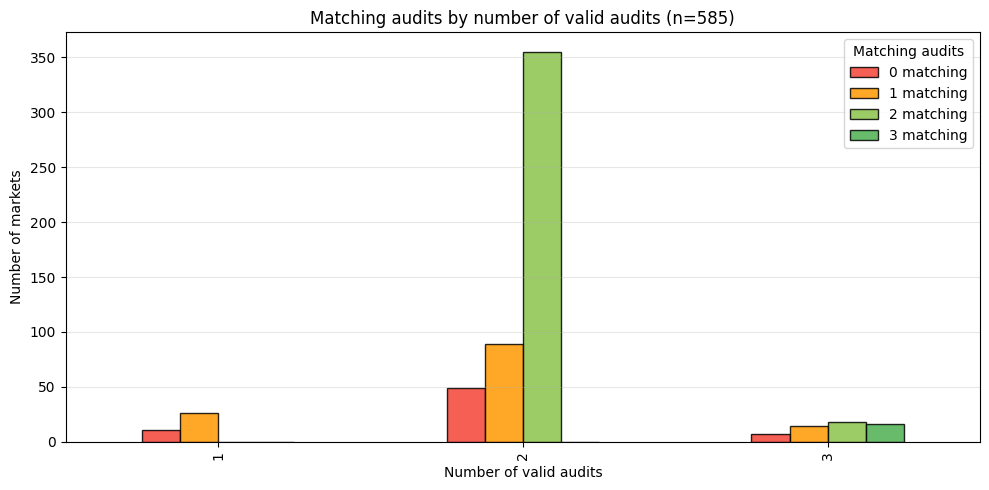

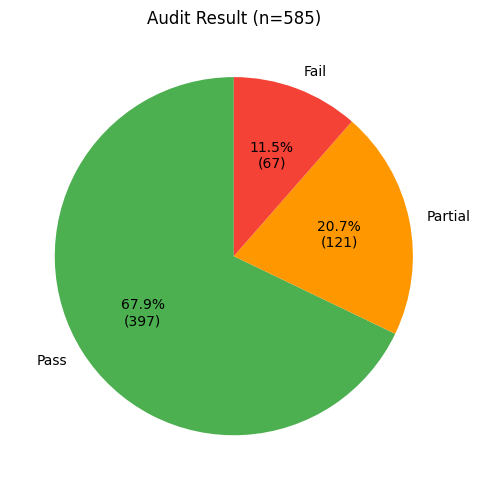

In [9]:
# Audit analysis uses pre-computed columns: n_audits, n_valid_audits, n_matching_audits

df_audited = df_markets[df_markets["n_audits"] > 0].copy()

n_markets = len(df_markets)
n_markets_invalid = int(df_markets["is_invalid"].sum())
n_audited = len(df_audited)
n_audited_invalid = int(df_audited["is_invalid"].sum())
n_audited_valid = n_audited - n_audited_invalid

# --- Overview ---
display(HTML("<h4>Audit overview</h4>"))
cols = ["Metric", "Count", "% over total", "% over audited"]
rows = [
    ("Total markets",           n_markets,         "100%",                        "\u2014"),
    ("Total invalid markets",   n_markets_invalid,  pct(n_markets_invalid, n_markets), "\u2014"),
    ("Audited markets",         n_audited,          pct(n_audited, n_markets),     "100%"),
    ("Audited invalid markets", n_audited_invalid,  pct(n_audited_invalid, n_markets), pct(n_audited_invalid, n_audited)),
    ("Audited valid markets",   n_audited_valid,    pct(n_audited_valid, n_markets),   pct(n_audited_valid, n_audited)),
]

# Add per-valid-audit-count rows
df_audited_valid = df_audited[~df_audited["is_invalid"]]
for n_valid in sorted(df_audited_valid["n_valid_audits"].unique()):
    count = int((df_audited_valid["n_valid_audits"] == n_valid).sum())
    rows.append((
        f"  with {n_valid} valid audit{'s' if n_valid != 1 else ''}",
        count,
        pct(count, n_markets),
        pct(count, n_audited),
    ))

# Add pass/partial/fail rows (only for markets with valid audits)
df_with_valid = df_audited_valid[df_audited_valid["n_valid_audits"] > 0]
n_with_valid = len(df_with_valid)
n_pass = int((df_with_valid["n_matching_audits"] == df_with_valid["n_valid_audits"]).sum())
n_fail = int((df_with_valid["n_matching_audits"] == 0).sum())
n_partial = n_with_valid - n_pass - n_fail
rows.append(("Audited - pass",    n_pass,    pct(n_pass, n_markets),    pct(n_pass, n_audited)))
rows.append(("Audited - partial pass", n_partial, pct(n_partial, n_markets), pct(n_partial, n_audited)))
rows.append(("Audited - fail",    n_fail,    pct(n_fail, n_markets),    pct(n_fail, n_audited)))

overview = pd.DataFrame(rows, columns=cols)
display(HTML(overview.to_html(escape=False, index=False)))

# --- Matching audits breakdown by valid audit count ---
if n_with_valid > 0:
    display(HTML("<h4>Matching audits by number of valid audits</h4>"))
    ct = pd.crosstab(df_with_valid["n_valid_audits"], df_with_valid["n_matching_audits"])
    totals = ct.sum(axis=1)
    ct_pct = ct.apply(lambda col: [f"{v} ({pct(v, totals[r])})" for r, v in col.items()])
    ct_pct.index = [f"{v} (n={totals[v]})" for v in ct_pct.index]
    ct_pct.index.name = "Valid audits"
    ct_pct.columns = [f"{c} match" for c in ct_pct.columns]
    display(HTML(ct_pct.to_html(escape=False)))

    # Grouped bar chart
    match_colors = ["#F44336", "#FF9800", "#8BC34A", "#4CAF50", "#2E7D32"]
    fig, ax = plt.subplots(figsize=(10, 5))
    ct.plot.bar(ax=ax, color=match_colors[:len(ct.columns)], edgecolor="black", alpha=0.85)
    ax.set_xlabel("Number of valid audits")
    ax.set_ylabel("Number of markets")
    ax.legend(title="Matching audits", labels=[f"{c} matching" for c in ct.columns])
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_title(f"Matching audits by number of valid audits (n={n_with_valid})")
    plt.tight_layout()
    plt.show()

    # --- Pass / Partial / Fail pie chart ---
    colors = {"Pass": "#4CAF50", "Partial": "#FF9800", "Fail": "#F44336"}
    pie_data = [(l, v) for l, v in [("Pass", n_pass), ("Partial", n_partial), ("Fail", n_fail)] if v > 0]

    if pie_data:
        fig, ax = plt.subplots(figsize=(6, 5))
        pie_labels, pie_values = zip(*pie_data)
        total_pv = sum(pie_values)
        ax.pie(
            pie_values, labels=pie_labels,
            colors=[colors[l] for l in pie_labels],
            autopct=lambda p, t=total_pv: f"{p:.1f}%\n({int(round(p * t / 100))})",
            startangle=90,
        )
        ax.set_title(f"Audit Result (n={total_pv})")
        plt.tight_layout()
        plt.show()

    # Accuracy
    denom = n_pass + n_fail
    if denom > 0:
        display(HTML(
            f"<h4>Accuracy</h4>"
            f"<p>Pass (all audits agree): <b>{n_pass}</b> &mdash; "
            f"Fail (no audit agrees): <b>{n_fail}</b><br>"
            f"Accuracy (pass / (pass + fail)): <b>{pct(n_pass, denom)}</b> ({n_pass}/{denom})</p>"
            f"<p><i>Excludes markets with partial agreement and markets with no valid audits.</i></p>"
        ))

### Challenged markets analysis

Markets where the initial answer was disputed via Realitio's bond escalation mechanism.
A market is considered **challenged** if it has more than one distinct answer submission or the current bond exceeds the initial bond (0.001 xDAI).

Metric,Value
Total closed markets,14960
Challenged,7419 (49.6%)
Not challenged,7541 (50.4%)


Creator,Closed,Challenged,% Challenged
QS Market Creator,12483,5964,47.8%
Pearl Market Creator,2477,1455,58.7%


# Challenges,Markets,%
1,7403,99.8%
2,16,0.2%


Outcome,Markets,%
Answer stayed (original won),7052,95.1%
Answer flipped (challenger won),256,3.5%
Resolved as Invalid,111,1.5%


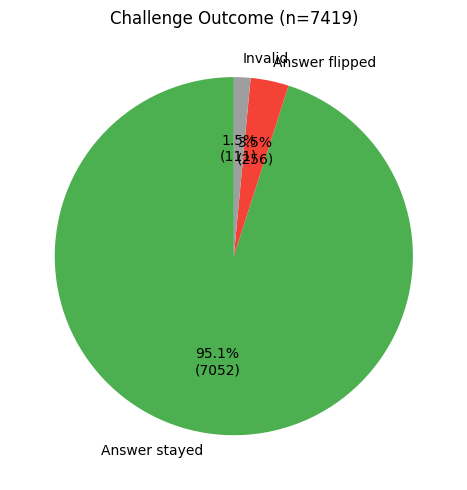

Metric,Bond (xDAI)
Min,0.0011
Median,10.0000
Mean,9.2529
Max,640.0000
Total,68647.0711


,Audited,Pass,Partial,Fail
Challenged,0,0 (—),0 (—),0 (—)
Not challenged,606,397 (65.5%),121 (20.0%),88 (14.5%)


In [10]:
from collections import Counter

# Filter to closed markets
_df_closed = df_markets[df_markets["state"] == MarketState.CLOSED].copy()
_df_challenged = _df_closed[_df_closed["is_challenged"]]
_df_not_challenged = _df_closed[~_df_closed["is_challenged"]]

n_closed = len(_df_closed)
n_challenged = len(_df_challenged)

# --- Overview ---
display(HTML("<h4>Challenge overview</h4>"))
overview_rows = [
    {"Metric": "Total closed markets", "Value": n_closed},
    {"Metric": "Challenged", "Value": f"{n_challenged} ({pct(n_challenged, n_closed)})"},
    {"Metric": "Not challenged", "Value": f"{n_closed - n_challenged} ({pct(n_closed - n_challenged, n_closed)})"},
]
display(HTML(pd.DataFrame(overview_rows).to_html(escape=False, index=False)))

if n_challenged > 0:
    # --- Per-creator breakdown ---
    display(HTML("<h4>Challenged markets by creator</h4>"))
    creator_rows = []
    for key in MARKET_CREATORS:
        name = MARKET_CREATORS[key]["name"]
        total_creator = len(_df_closed[_df_closed["creator"] == key])
        chall_creator = len(_df_challenged[_df_challenged["creator"] == key])
        if total_creator == 0:
            continue
        creator_rows.append({
            "Creator": name,
            "Closed": total_creator,
            "Challenged": chall_creator,
            "% Challenged": pct(chall_creator, total_creator),
        })
    display(HTML(pd.DataFrame(creator_rows).to_html(escape=False, index=False)))

    # --- Number of challenges per market ---
    display(HTML("<h4>Number of challenges per market</h4>"))
    display(HTML("<p><i>Each distinct answer beyond the first counts as a challenge. "
                 "Bond-only escalation (same answer, higher bond) counts as 1.</i></p>"))
    chall_counter = _df_challenged["n_challenges"].value_counts().sort_index()
    chall_rows = [
        {"# Challenges": n_ch, "Markets": count, "%": pct(count, n_challenged)}
        for n_ch, count in chall_counter.items()
    ]
    display(HTML(pd.DataFrame(chall_rows).to_html(escape=False, index=False)))

    # --- Did the challenge flip the answer? ---
    display(HTML("<h4>Challenge outcome — did the answer flip?</h4>"))
    flipped = len(_df_challenged[_df_challenged["is_flipped"]])
    invalid_final = len(_df_challenged[_df_challenged["is_invalid"]])
    stayed = n_challenged - flipped - invalid_final

    outcome_rows = [
        {"Outcome": "Answer stayed (original won)", "Markets": stayed,
         "%": pct(stayed, n_challenged)},
        {"Outcome": "Answer flipped (challenger won)", "Markets": flipped,
         "%": pct(flipped, n_challenged)},
        {"Outcome": "Resolved as Invalid", "Markets": invalid_final,
         "%": pct(invalid_final, n_challenged)},
    ]
    display(HTML(pd.DataFrame(outcome_rows).to_html(escape=False, index=False)))

    # Pie chart
    outcome_colors_map = {"Answer stayed": "#4CAF50", "Answer flipped": "#F44336", "Invalid": "#9E9E9E"}
    pie_data = [(l, v) for l, v in [("Answer stayed", stayed), ("Answer flipped", flipped), ("Invalid", invalid_final)] if v > 0]

    if pie_data:
        fig, ax = plt.subplots(figsize=(6, 5))
        pie_labels, pie_values = zip(*pie_data)
        oc_colors = [outcome_colors_map[l] for l in pie_labels]
        total_oc = sum(pie_values)
        ax.pie(
            pie_values, labels=pie_labels, colors=oc_colors,
            autopct=lambda p, t=total_oc: f"{p:.1f}%\n({int(round(p * t / 100))})",
            startangle=90,
        )
        ax.set_title(f"Challenge Outcome (n={n_challenged})")
        plt.tight_layout()
        plt.show()

    # --- Bond escalation ---
    display(HTML("<h4>Bond escalation</h4>"))
    bonds_xdai = _df_challenged["current_answer_bond"] / 1e18
    bond_stats = {
        "Metric": ["Min", "Median", "Mean", "Max", "Total"],
        "Bond (xDAI)": [
            f"{bonds_xdai.min():.4f}",
            f"{bonds_xdai.median():.4f}",
            f"{bonds_xdai.mean():.4f}",
            f"{bonds_xdai.max():.4f}",
            f"{bonds_xdai.sum():.4f}",
        ],
    }
    display(HTML(pd.DataFrame(bond_stats).to_html(escape=False, index=False)))

    # --- Cross-reference with audit data (using pre-computed columns) ---
    if df_markets["n_audits"].sum() > 0:
        display(HTML("<h4>Challenged markets vs audit agreement</h4>"))

        def _audit_result(row):
            if row["n_audits"] == 0 or row["n_valid_audits"] == 0:
                return "no_audit"
            if row["n_matching_audits"] == row["n_valid_audits"]:
                return "pass"
            elif row["n_matching_audits"] > 0:
                return "partial"
            return "fail"

        _df_closed_with_audit = _df_closed.copy()
        _df_closed_with_audit["audit_result"] = _df_closed_with_audit.apply(_audit_result, axis=1)

        def _cross_row(label, subset):
            audited = subset[subset["audit_result"] != "no_audit"]
            n = len(audited)
            return {
                "": label,
                "Audited": n,
                "Pass": f"{len(audited[audited['audit_result'] == 'pass'])} ({pct(len(audited[audited['audit_result'] == 'pass']), n)})",
                "Partial": f"{len(audited[audited['audit_result'] == 'partial'])} ({pct(len(audited[audited['audit_result'] == 'partial']), n)})",
                "Fail": f"{len(audited[audited['audit_result'] == 'fail'])} ({pct(len(audited[audited['audit_result'] == 'fail']), n)})",
            }

        chall_subset = _df_closed_with_audit[_df_closed_with_audit["is_challenged"]]
        unchall_subset = _df_closed_with_audit[~_df_closed_with_audit["is_challenged"]]

        cross_rows = [_cross_row("Challenged", chall_subset), _cross_row("Not challenged", unchall_subset)]
        display(HTML(pd.DataFrame(cross_rows).to_html(escape=False, index=False)))
        display(HTML(
            "<p><i>Pass = all valid audits agree with market answer. "
            "Fail = no audit agrees. Higher fail rate among challenged markets "
            "suggests challenges correlate with incorrect initial answers.</i></p>"
        ))

In [11]:
from omen_markets import INVALID_ANSWER_HEX

def _answer_hex_to_label(hex_val, outcomes):
    """Convert hex answer to human-readable label."""
    if not hex_val:
        return "N/A"
    if hex_val.lower() == INVALID_ANSWER_HEX.lower():
        return "Invalid"
    try:
        idx = int(hex_val, 16)
        return outcomes[idx] if idx < len(outcomes) else f"Index {idx}"
    except (ValueError, IndexError):
        return hex_val[:10]

# Filter flipped markets from df_markets
_df_flipped = _df_challenged[_df_challenged["is_flipped"] & ~_df_challenged["is_invalid"]].copy()
_df_flipped = _df_flipped.sort_values("finalized_ts", ascending=False, na_position="last")

_flip_rows = []
for _, row in _df_flipped.iterrows():
    presagio_url = f'https://presagio.pages.dev/markets?id={row["market_id"]}'
    title_text = (row["title"] or "")[:80]
    outcomes = row["outcomes"] or []

    first_label = _answer_hex_to_label(row["first_answer_hex"], outcomes)
    bond_xdai = row["current_answer_bond"] / 1e18

    # Audit info from pre-computed columns
    audit_str = ""
    if row["n_audits"] > 0:
        m, v, t = row["n_matching_audits"], row["n_valid_audits"], row["n_audits"]
        if v > 0:
            icon = "\U0001f7e2" if m == v else ("\U0001f7e1" if m > 0 else "\U0001f534")
            audit_str = f"{m}/{v}/{t} {icon}"

    creator_name = MARKET_CREATORS.get(row["creator"], {}).get("name", row["creator"])

    _flip_rows.append({
        "Title": f'<a href="{presagio_url}" target="_blank">{title_text}</a>',
        "Creator": creator_name,
        "# Answers": row["n_answers"],
        "First answer": first_label,
        "Final answer": row["current_answer"],
        "Bond (xDAI)": f"{bond_xdai:.4f}",
        "Audit": audit_str,
        "Answered (UTC)": row["finalized_ts"].strftime("%Y-%m-%d %H:%M") if pd.notna(row["finalized_ts"]) else "--",
    })

display(HTML(f"<h4>Flipped markets ({len(_df_flipped)})</h4>"))
if _flip_rows:
    display(HTML(pd.DataFrame(_flip_rows).to_html(escape=False, index=False)))
else:
    display(HTML("<p><i>No flipped markets found.</i></p>"))

Title,Creator,# Answers,First answer,Final answer,Bond (xDAI),Audit,Answered (UTC)
"Will the American Psychiatric Association publicly announce, on or before Septem",QS Market Creator,2,Yes,No,20.0000,,2025-09-16 08:12
"Will the American Diabetes Association publicly announce, on or before September",QS Market Creator,2,Yes,No,20.0000,,2025-09-16 07:57
"Will the Liberal Democratic Party of Japan publicly announce, on or before Octob",Pearl Market Creator,2,Yes,No,20.0000,,2025-09-15 09:23
Will President Donald Trump host a public meeting with at least three CEOs from,QS Market Creator,2,Yes,No,10.0000,,2025-09-13 12:39
"Will the Israeli government publicly announce, on or before September 11, 2025,",Pearl Market Creator,2,Yes,No,20.0000,,2025-09-13 09:43
Will the Powerball jackpot be won by a single ticket matching all five white bal,QS Market Creator,2,Yes,No,10.0000,,2025-09-09 06:39
Will President Donald Trump sign an executive order requiring voter ID for all f,Pearl Market Creator,2,Yes,No,10.0000,,2025-09-08 12:40
"Will the American Heart Association publicly announce, on or before September 5,",QS Market Creator,2,Yes,No,20.0000,,2025-09-08 09:23
Will the U.S. Attorney's Office for the Eastern District of New York publicly an,QS Market Creator,2,Yes,No,20.0000,,2025-09-05 09:24
Will any Premier League club publicly announce the signing of a player for a tra,QS Market Creator,2,Yes,No,20.0000,,2025-08-29 16:36


## Mech Requests

Fetch all mech requests made by each market creator and their associated delivers.

The market creator uses the Realitio **question ID as the nonce** for mech requests.
When a response is `not_determinable`, it retries with the same nonce but the subgraph
assigns a new request ID each time.

Data is cached to `notebooks/.cache/mech_requests_<address>.json` — already-delivered
requests with IPFS contents won't be re-fetched.

In [12]:
from mech_requests import fetch_mech_requests, mech_requests_to_dataframe

mech_data = {
    key: fetch_mech_requests(cfg["safe_contract_address"])
    for key, cfg in MARKET_CREATORS.items()
}

# Build combined mech requests DataFrame across all creators
df_mech = pd.concat(
    [
        mech_requests_to_dataframe(reqs).assign(creator=key)
        for key, reqs in mech_data.items()
    ],
    ignore_index=True,
)

print(f"df_mech: {len(df_mech)} rows, columns: {list(df_mech.columns)}")
df_mech.tail(2)


Fetching mech requests for 0x89c5cc945dd550bcffb72fe42bff002429f46fec...
  Resuming from checkpoint 2026-03-14 22:40 UTC
  10623 requests
Fetching mech requests for 0xffc8029154ecd55abed15bd428ba596e7d23f557...
  Resuming from checkpoint 2026-03-14 22:40 UTC
  2493 requests
df_mech: 13116 rows, columns: ['request_id', 'sender', 'request_ts', 'nonce', 'has_deliver', 'deliver_ts', 'deliver_delay_seconds', 'result_category', 'creator']


,request_id,sender,request_ts,nonce,has_deliver,deliver_ts,deliver_delay_seconds,result_category,creator
13114,0xfff571c75f6abd3de2bb225777f143a60b2b346bfc95...,0xffc8029154ecd55abed15bd428ba596e7d23f557,2025-09-07 00:19:30+00:00,0x921e0061275324ca4963061bede3b4af9acf6239767c...,False,NaT,NaN,No delivery,pearl
13115,0xffffd454423a2c6ef2f1ada3a3b53d1057844b8bcda4...,0xffc8029154ecd55abed15bd428ba596e7d23f557,2025-08-20 01:23:20+00:00,0xb12cc8c3cb91b9e316864b5689c5cd12b95b6e6dd928...,True,2025-08-20 01:24:15+00:00,55.0,is_determinable=False,pearl


In [13]:
for key in MARKET_CREATORS:
    name = MARKET_CREATORS[key]["name"]
    df_creator = df_mech[df_mech["creator"] == key]

    total = len(df_creator)
    with_deliver = df_creator["has_deliver"].sum()
    without_deliver = total - with_deliver

    # Unique nonces (= unique markets) and retries
    nonce_counts = df_creator[df_creator["nonce"].notna()].groupby("nonce").size()
    unique_markets = len(nonce_counts)
    retried = (nonce_counts > 1).sum()

    display(HTML(f"<h4>{name}</h4>"))
    display(HTML(
        f"<ul>"
        f"<li>Total requests: <b>{total}</b></li>"
        f"<li>With delivery: <b>{int(with_deliver)}</b></li>"
        f"<li>Without delivery: <b>{int(without_deliver)}</b></li>"
        f"<li>Unique markets (nonces): <b>{unique_markets}</b></li>"
        f"<li>Markets with retries: <b>{retried}</b></li>"
        f"</ul>"
    ))

### Mech result distribution

Distribution of mech deliver results, categorized by the first key-value pair of the JSON response, or **Error** if the response is not valid JSON.

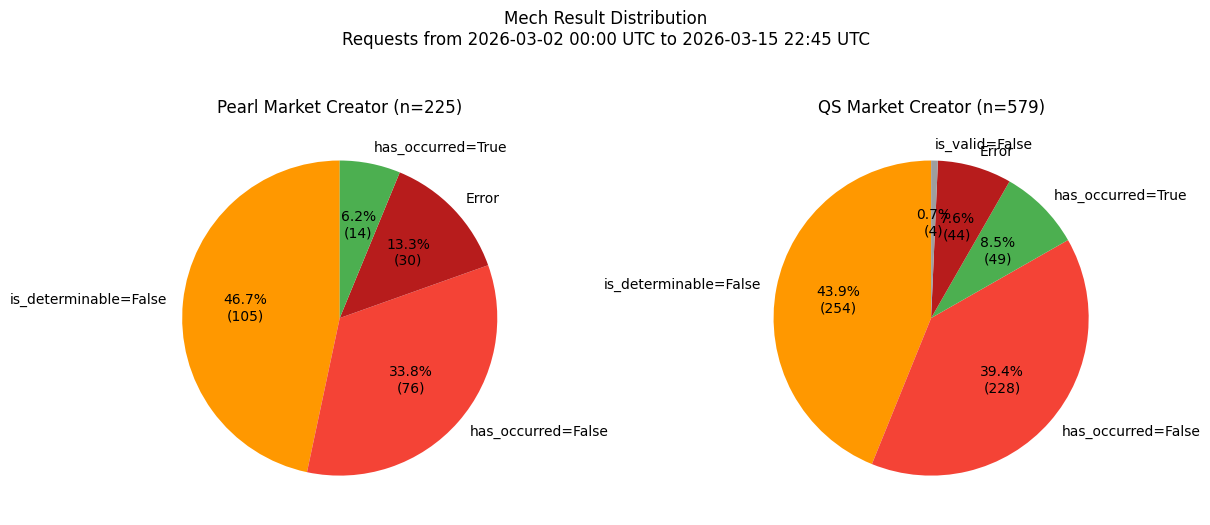

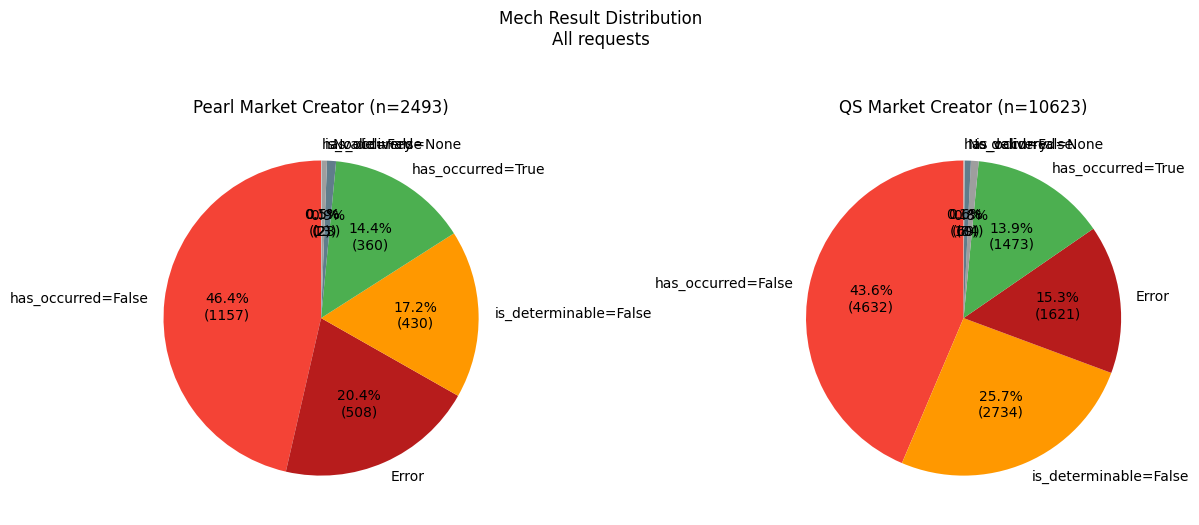

In [14]:
RESULT_COLORS = {
    "has_occurred=True": "#4CAF50",
    "has_occurred=False": "#F44336",
    "has_occurred=None": "#BDBDBD",
    "is_determinable=False": "#FF9800",
    "is_valid=False": "#9E9E9E",
    "Error": "#B71C1C",
    "No delivery": "#607D8B",
}


def _plot_mech_result_distribution(df_mc, subtitle):
    """Plot mech result distribution pie charts, one per creator."""
    creators = sorted(df_mc["creator"].unique())
    n = max(len(creators), 1)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, key in zip(axes, creators):
        name = MARKET_CREATORS[key]["name"]
        counts = df_mc[df_mc["creator"] == key]["result_category"].value_counts()

        if counts.empty:
            ax.set_title(f"{name}\n(no requests)")
            ax.axis("off")
            continue

        labels = counts.index.tolist()
        values = counts.values.tolist()
        colors = [RESULT_COLORS.get(l, "#607D8B") for l in labels]
        total = sum(values)
        ax.pie(
            values, labels=labels, colors=colors,
            autopct=lambda pct, t=total: f"{pct:.1f}%\n({int(round(pct * t / 100))})",
            startangle=90, textprops={"fontsize": 10},
        )
        ax.set_title(f"{name} (n={total})")

    fig.suptitle(f"Mech Result Distribution\n{subtitle}", y=1.04)
    plt.tight_layout()
    plt.show()


_df_mech_period = df_mech[(df_mech["request_ts"] >= period_start) & (df_mech["request_ts"] <= period_end)]

# Study period
_plot_mech_result_distribution(_df_mech_period, f"Requests {_period_label}")

# Overall
_plot_mech_result_distribution(df_mech, "All requests")

### Mech requests per market

Number of mech requests (including retries) associated with each closed market, matched via the Realitio question ID (= mech nonce).

Creator,0 reqs,1 req,2 reqs,3 reqs,4 reqs,5 reqs,6 reqs,7 reqs,8 reqs,9 reqs,10 reqs,11 reqs,13 reqs,18 reqs
Pearl Market Creator (n=81),2 (2.5%),49 (60.5%),15 (18.5%),3 (3.7%),2 (2.5%),2 (2.5%),2 (2.5%),1 (1.2%),0 (0.0%),1 (1.2%),2 (2.5%),1 (1.2%),1 (1.2%),0 (0.0%)
QS Market Creator (n=204),13 (6.4%),126 (61.8%),35 (17.2%),11 (5.4%),5 (2.5%),3 (1.5%),3 (1.5%),3 (1.5%),1 (0.5%),2 (1.0%),1 (0.5%),0 (0.0%),0 (0.0%),1 (0.5%)


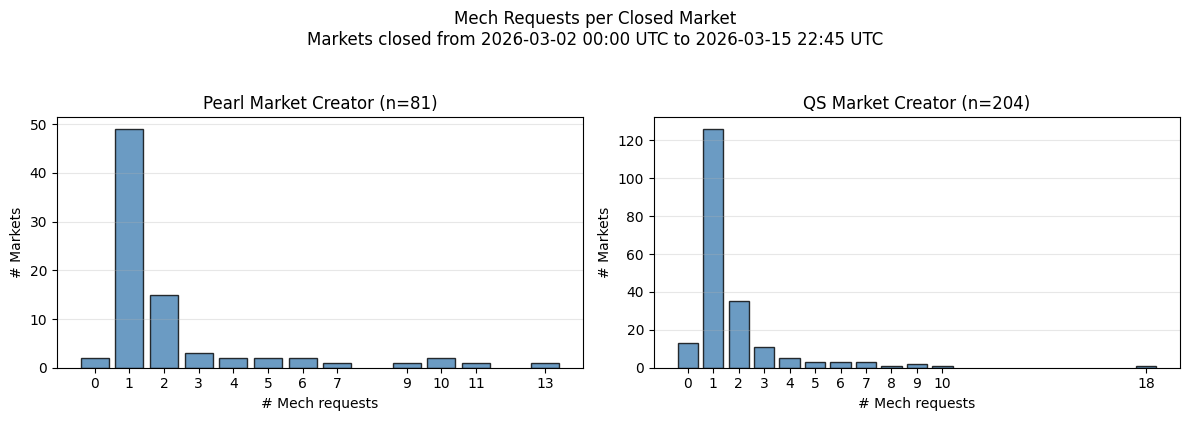

Creator,0 reqs,1 req,2 reqs,3 reqs,4 reqs,5 reqs,6 reqs,7 reqs,8 reqs,9 reqs,10 reqs,11 reqs,12 reqs,13 reqs,14 reqs,15 reqs,16 reqs,17 reqs,18 reqs,19 reqs,20 reqs,21 reqs,22 reqs,23 reqs,24 reqs,25 reqs,26 reqs,27 reqs,28 reqs,29 reqs,30 reqs,32 reqs,36 reqs,37 reqs,38 reqs,39 reqs,41 reqs,42 reqs,46 reqs,53 reqs,55 reqs,56 reqs,57 reqs,65 reqs
Pearl Market Creator (n=2477),413 (16.7%),1942 (78.4%),49 (2.0%),24 (1.0%),13 (0.5%),7 (0.3%),6 (0.2%),6 (0.2%),5 (0.2%),4 (0.2%),3 (0.1%),2 (0.1%),1 (0.0%),1 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
QS Market Creator (n=12483),5495 (44.0%),6324 (50.7%),268 (2.1%),102 (0.8%),55 (0.4%),36 (0.3%),37 (0.3%),21 (0.2%),22 (0.2%),18 (0.1%),12 (0.1%),11 (0.1%),10 (0.1%),4 (0.0%),7 (0.1%),5 (0.0%),5 (0.0%),2 (0.0%),4 (0.0%),3 (0.0%),6 (0.0%),2 (0.0%),5 (0.0%),3 (0.0%),1 (0.0%),1 (0.0%),2 (0.0%),2 (0.0%),1 (0.0%),1 (0.0%),1 (0.0%),1 (0.0%),1 (0.0%),1 (0.0%),2 (0.0%),1 (0.0%),1 (0.0%),1 (0.0%),1 (0.0%),1 (0.0%),2 (0.0%),3 (0.0%),1 (0.0%),1 (0.0%)


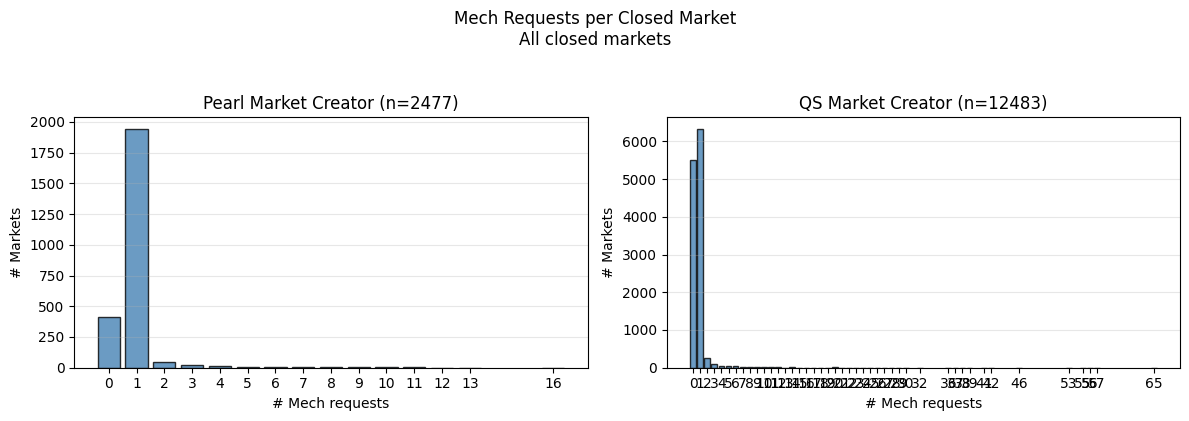

In [15]:
def _display_mech_per_market(df_mkts, df_mc, subtitle):
    """Display table + bar chart of mech requests per closed market using DataFrames."""
    # Filter to closed markets
    closed = df_mkts[df_mkts["state"] == MarketState.CLOSED].copy()

    # Count mech requests per question_id (nonce)
    mech_per_nonce = df_mc.groupby(["creator", "nonce"]).size().reset_index(name="n_reqs")

    # Merge: for each closed market, how many mech requests?
    merged = closed.merge(
        mech_per_nonce,
        left_on=["creator", "question_id"],
        right_on=["creator", "nonce"],
        how="left",
    )
    merged["n_reqs"] = merged["n_reqs"].fillna(0).astype(int)

    if len(merged) == 0:
        display(HTML(f"<h4>Mech requests per closed market — {subtitle}</h4>"))
        display(HTML("<p><i>No closed markets.</i></p>"))
        return

    # Summary table by creator
    all_values = sorted(merged["n_reqs"].unique())
    creators = sorted(merged["creator"].unique())
    table_rows = []
    for key in creators:
        name = MARKET_CREATORS[key]["name"]
        subset = merged[merged["creator"] == key]
        total = len(subset)
        if total == 0:
            continue
        counter = subset["n_reqs"].value_counts()
        row = {"Creator": f"{name} (n={total})"}
        for v in all_values:
            c = counter.get(v, 0)
            row[f"{v} req{'s' if v != 1 else ''}"] = f"{c} ({pct(c, total)})"
        table_rows.append(row)

    display(HTML(f"<h4>Mech requests per closed market — {subtitle}</h4>"))
    display(HTML(pd.DataFrame(table_rows).fillna("").to_html(escape=False, index=False)))

    # Bar chart per creator
    n_creators = len(creators)
    fig, axes = plt.subplots(1, max(n_creators, 1), figsize=(6 * max(n_creators, 1), 4))
    if n_creators == 1:
        axes = [axes]

    for ax, key in zip(axes, creators):
        name = MARKET_CREATORS[key]["name"]
        subset = merged[merged["creator"] == key]
        counter = subset["n_reqs"].value_counts().sort_index()
        x = counter.index.tolist()
        y = counter.values.tolist()
        total = sum(y)
        ax.bar(x, y, color="steelblue", edgecolor="black", alpha=0.8)
        ax.set_xlabel("# Mech requests")
        ax.set_ylabel("# Markets")
        ax.set_xticks(x)
        ax.grid(True, alpha=0.3, axis="y")
        ax.set_title(f"{name} (n={total})")

    fig.suptitle(f"Mech Requests per Closed Market\n{subtitle}", y=1.04)
    plt.tight_layout()
    plt.show()


# Period markets: closed within [period_start, period_end]
_df_markets_period = df_markets[
    (df_markets["finalized_ts"] >= period_start) & (df_markets["finalized_ts"] <= period_end)
]

# Study period
_display_mech_per_market(_df_markets_period, _df_mech_period, f"Markets closed {_period_label}")

# Overall
_display_mech_per_market(df_markets, df_mech, "All closed markets")

### Mech deliver delay

Time between the mech request and its delivery, measured in **blocks** and **seconds** (`deliver - request`).

QS Market Creator (blocks): n=579, mean=19.9, var=119.0, min=6.0, max=77.0
  Filtered 3 outliers (>5σ)
Pearl Market Creator (blocks): n=225, mean=20.5, var=167.7, min=5.0, max=74.0
QS Market Creator (seconds): n=579, mean=102.9, var=3146.7, min=30.0, max=395.0
  Filtered 3 outliers (>5σ)
Pearl Market Creator (seconds): n=225, mean=106.4, var=4523.5, min=25.0, max=380.0


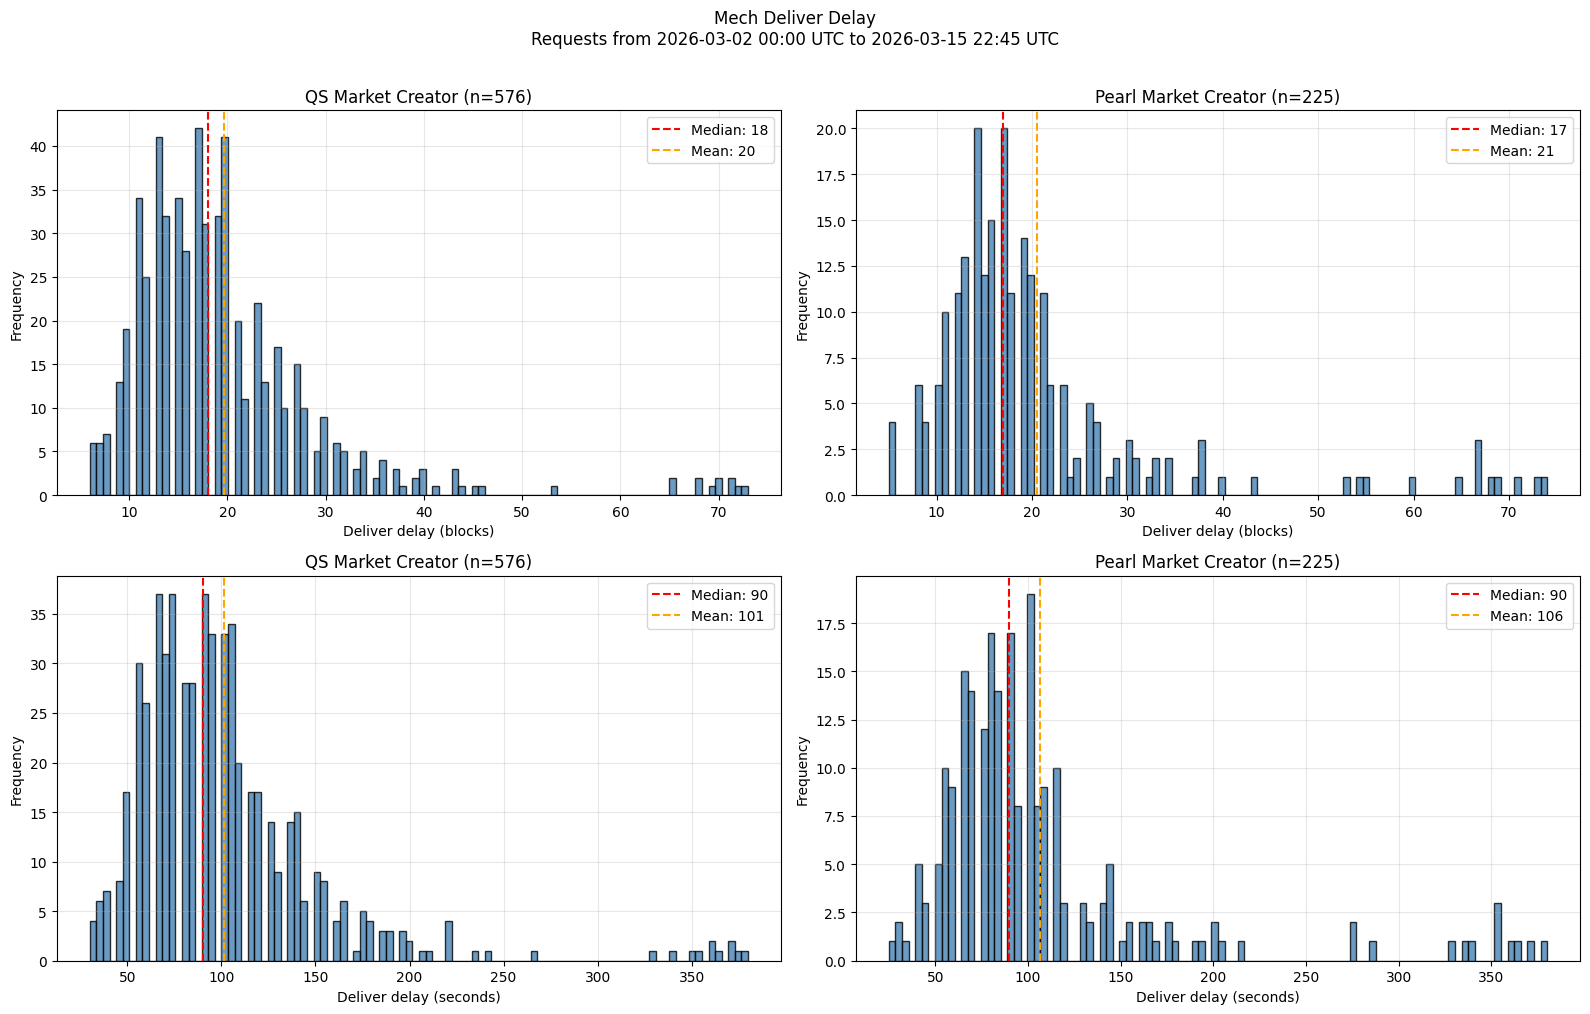

In [16]:
import numpy as np
from scipy import stats

def _plot_delay_histogram(axes_row, df_mc, creators_config, value_col, xlabel, unit):
    """Plot deliver delay histograms for each creator."""
    delivered = df_mc[df_mc["has_deliver"]].copy()

    for ax, key in zip(axes_row, creators_config):
        name = creators_config[key]["name"]
        subset = delivered[delivered["creator"] == key]
        delays = subset[value_col].dropna()
        delays = delays[delays >= 0].tolist()

        if not delays:
            ax.set_title(f"{name}\n(no delivers)")
            ax.axis("off")
            continue

        desc = stats.describe(delays)
        print(f"{name} ({unit}): n={desc.nobs}, mean={desc.mean:.1f}, var={desc.variance:.1f}, "
              f"min={desc.minmax[0]}, max={desc.minmax[1]}")

        mean = desc.mean
        std = np.sqrt(desc.variance)
        filtered = [d for d in delays if abs(d - mean) <= 5 * std]
        n_outliers = len(delays) - len(filtered)
        if n_outliers > 0:
            print(f"  Filtered {n_outliers} outliers (>5σ)")

        ax.hist(filtered, bins=100, color="steelblue", edgecolor="black", alpha=0.8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Frequency")

        median_d = float(np.median(filtered))
        mean_d = float(np.mean(filtered))
        ax.axvline(median_d, color="red", linestyle="--", linewidth=1.5, label=f"Median: {median_d:.0f}")
        ax.axvline(mean_d, color="orange", linestyle="--", linewidth=1.5, label=f"Mean: {mean_d:.0f}")
        ax.legend()
        ax.set_title(f"{name} (n={len(filtered)})")
        ax.grid(True, alpha=0.3)


# Add delay_blocks column (not available from mech_requests_to_dataframe)
_block_delays = {}
for reqs in mech_data.values():
    for rid, r in reqs.items():
        if "deliver" in r:
            _block_delays[rid] = int(r["deliver"]["blockNumber"]) - int(r["blockNumber"])
df_mech["delay_blocks"] = df_mech["request_id"].map(_block_delays)

# Re-filter period df to include new column
_df_mech_period = df_mech[(df_mech["request_ts"] >= period_start) & (df_mech["request_ts"] <= period_end)]

n_creators = max(len(MARKET_CREATORS), 1)
fig, axes = plt.subplots(2, n_creators, figsize=(8 * n_creators, 10))
if n_creators == 1:
    axes = axes.reshape(2, 1)

_plot_delay_histogram(axes[0], _df_mech_period, MARKET_CREATORS, "delay_blocks", "Deliver delay (blocks)", "blocks")
_plot_delay_histogram(axes[1], _df_mech_period, MARKET_CREATORS, "deliver_delay_seconds", "Deliver delay (seconds)", "seconds")

fig.suptitle(f"Mech Deliver Delay\nRequests {_period_label}", y=1.01)
plt.tight_layout()
plt.show()

### Latest mech requests

Most recent requests with their associated responses. Request and deliver IDs link to their IPFS contents.

In [17]:
import json
from mech_requests import get_request_ipfs_url, get_deliver_ipfs_url

LATEST_MECH_REQUESTS = 20

for key, reqs in mech_data.items():
    name = MARKET_CREATORS[key]["name"]

    # Sort by blockTimestamp descending
    sorted_reqs = sorted(reqs.values(), key=lambda r: int(r["blockTimestamp"]), reverse=True)

    rows = []
    for r in sorted_reqs[:LATEST_MECH_REQUESTS]:
        req_ts = datetime.fromtimestamp(int(r["blockTimestamp"]), tz=timezone.utc)
        request_url = get_request_ipfs_url(r)

        deliver_id = ""
        deliver_date = ""
        delay = ""
        response_display = ""

        if "deliver" in r:
            d = r["deliver"]
            deliver_url = get_deliver_ipfs_url(d)
            deliver_ts = datetime.fromtimestamp(int(d["blockTimestamp"]), tz=timezone.utc)
            delay_s = int(d["blockTimestamp"]) - int(r["blockTimestamp"])
            deliver_id = (
                f'<a href="{deliver_url}" target="_blank">{d["id"][:16]}...</a>'
                if deliver_url else d["id"][:16] + "..."
            )
            deliver_date = deliver_ts.strftime("%Y-%m-%d %H:%M")
            delay = f"{delay_s}s"

            if "ipfsContents" in d:
                raw = str(d["ipfsContents"].get("result", ""))
                truncated = raw[:100] + ("..." if len(raw) > 100 else "")
                try:
                    parsed = json.loads(raw)
                    is_ok = isinstance(parsed, dict) and parsed
                except (json.JSONDecodeError, TypeError, ValueError):
                    is_ok = False
                if is_ok:
                    response_display = truncated
                else:
                    response_display = f'<span style="color:red">{truncated}</span> \U0001f534'

        rows.append({
            "Request ID": f'<a href="{request_url}" target="_blank">{r["id"][:16]}...</a>',
            "Deliver ID": deliver_id,
            "Request date": req_ts.strftime("%Y-%m-%d %H:%M"),
            "Deliver date": deliver_date,
            "Delay": delay,
            "Response": response_display,
        })

    display(HTML(f"<h4>{name} — Last {LATEST_MECH_REQUESTS} requests</h4>"))
    if rows:
        display(HTML(pd.DataFrame(rows).to_html(escape=False, index=False)))
    else:
        display(HTML("<p><i>No mech requests.</i></p>"))

Request ID,Deliver ID,Request date,Deliver date,Delay,Response
0x59b48f3cde5469...,0x5ee40f52eef89b...,2026-03-15 07:48,2026-03-15 07:50,95s,"{""has_occurred"":true}"
0x4aa8af94bbcdee...,0xfcb3482023894a...,2026-03-15 04:33,2026-03-15 04:34,60s,"{""has_occurred"":false}"
0xe801d4fba11c61...,0xdbc2023bce998c...,2026-03-15 04:21,2026-03-15 04:22,60s,"{""is_determinable"":false}"
0x9968ec7f4ea8aa...,0xd22ef1ef798c3e...,2026-03-15 04:15,2026-03-15 04:16,60s,"{""is_determinable"":false}"
0x37615fe8a61dee...,0x132dff8bb825f2...,2026-03-15 04:08,2026-03-15 04:09,70s,"{""is_determinable"":false}"
0x17df5df8996052...,0xe25d96d6e4a1e0...,2026-03-15 04:01,2026-03-15 04:03,95s,"{""is_determinable"":false}"
0x18c917c11623b5...,0x1921c06545c31b...,2026-03-15 03:54,2026-03-15 03:56,70s,"not enough values to unpack (expected 2, got 1)"
0x25af1b4debc2b4...,0x097b94c272b0aa...,2026-03-15 03:47,2026-03-15 03:49,115s,"{""is_determinable"":false}"
0xfe993874440e6c...,0xe38d92d2c46d9e...,2026-03-15 03:41,2026-03-15 03:42,65s,"{""is_determinable"":false}"
0xe8b4b02def0640...,0x85e6610b4bc21a...,2026-03-15 03:34,2026-03-15 03:35,35s,"{""is_determinable"":false}"


Request ID,Deliver ID,Request date,Deliver date,Delay,Response
0x7c0c009bf42d8f...,0x3a008f92db0456...,2026-03-15 03:24,2026-03-15 03:25,85s,"{""is_determinable"":false}"
0x0aa9f02d7b7847...,0x0606fe437757d8...,2026-03-15 03:12,2026-03-15 03:13,45s,"{""has_occurred"":false}"
0x218b501794d56e...,0x13354dd967bb8d...,2026-03-15 03:00,2026-03-15 03:01,70s,"{""has_occurred"":false}"
0x0cf544019cb47b...,0x5e0d6c70c7bcfa...,2026-03-15 02:48,2026-03-15 02:50,100s,"{""is_determinable"":false}"
0xab8be28b4026fa...,0x7ddd89ccc8813a...,2026-03-15 02:37,2026-03-15 02:38,40s,"{""is_determinable"":false}"
0x1708f39196819a...,0x561a3cf1bf77dd...,2026-03-15 02:25,2026-03-15 02:26,85s,"{""has_occurred"":false}"
0x5fae4c2ed5b9be...,0x559df1d3f98cd3...,2026-03-15 02:12,2026-03-15 02:13,80s,"{""has_occurred"":false}"
0x83a1ebe077110d...,0xb811c7e6f90317...,2026-03-15 01:59,2026-03-15 02:01,100s,"{""has_occurred"":false}"
0x7d366b48d816a9...,0xd0286659e5e34a...,2026-03-15 01:54,2026-03-15 01:55,70s,"{""has_occurred"":false}"
0x2f5ffe7c4034de...,0x111b560ec715b7...,2026-03-15 01:42,2026-03-15 01:43,25s,"{""is_determinable"":false}"


## Markets + Mech Requests

Join markets with their associated mech requests via the Realitio question ID (= mech nonce).
Each market may have multiple mech requests (retries after `not_determinable`).

Use the widget below to filter by market state.

In [ ]:
import json
from mech_requests import get_deliver_ipfs_url, categorize_mech_result

# Configure which states to display and max rows
MARKET_TABLE_STATES = [
    MarketState.OPEN,
    MarketState.PENDING,
    MarketState.FINALIZING,
    MarketState.ARBITRATING,
    # MarketState.CLOSED,
    MarketState.UNKNOWN,
]
MAX_MARKETS_DISPLAYED = 200

# Build nonce -> sorted mech requests from raw data (for deliver URL formatting)
def _build_nonce_index(reqs):
    from collections import defaultdict
    index = defaultdict(list)
    for r in reqs.values():
        try:
            import json
            content = json.loads(r["parsedRequest"]["content"])
            nonce = content.get("nonce", "")
            if nonce:
                index[nonce].append(r)
        except (json.JSONDecodeError, KeyError, TypeError):
            pass
    for nonce in index:
        index[nonce].sort(key=lambda r: int(r["blockTimestamp"]))
    return index

def _is_failed_deliver(r):
    """Check if a raw mech request dict has a failed delivery."""
    d = r.get("deliver")
    if not d or "ipfsContents" not in d:
        return True
    result_str = str(d["ipfsContents"].get("result", ""))
    try:
        parsed = json.loads(result_str)
        return not (isinstance(parsed, dict) and parsed)
    except (json.JSONDecodeError, TypeError, ValueError):
        return True

def _format_delivers(mech_reqs):
    n = len(mech_reqs)
    parts = []
    for i, r in enumerate(reversed(mech_reqs), 0):
        label = n - i
        if "deliver" in r:
            url = get_deliver_ipfs_url(r["deliver"])
            failed = _is_failed_deliver(r)
            icon = " \U0001f534" if failed else ""
            parts.append(f'<a href="{url}" target="_blank">[{label}]{icon}</a>' if url else f"[{label}]{icon}")
        else:
            parts.append("[X \U0001f534]")
    return "".join(parts)

def _format_mech_response(mech_reqs):
    for r in reversed(mech_reqs):
        if "deliver" in r and "ipfsContents" in r.get("deliver", {}):
            raw = str(r["deliver"]["ipfsContents"].get("result", ""))
            cat = categorize_mech_result(raw)
            if _is_failed_deliver(r):
                return f"{cat} \U0001f534"
            return cat
    return ""

def _format_audit_info(row):
    """Format audit info from pre-computed DataFrame columns."""
    if row["n_audits"] == 0:
        return ""
    m, v, t = row["n_matching_audits"], row["n_valid_audits"], row["n_audits"]
    if v == 0:
        return f"{m}/{v}/{t}"
    icon = "\U0001f7e2" if m == v else ("\U0001f7e1" if m > 0 else "\U0001f534")
    return f"{m}/{v}/{t} {icon}"


# State summary table with icons in headers
df_states_display = df_states.rename(
    columns={col: f"{col} {MARKET_STATE_ICONS.get(col, '')}" for col in df_states.columns}
)
display(HTML(df_states_display.to_html()))

state_set = set(MARKET_TABLE_STATES)

for key in MARKET_CREATORS:
    name = MARKET_CREATORS[key]["name"]

    # Filter markets using df_markets
    df_creator = df_markets[(df_markets["creator"] == key) & (df_markets["state"].isin(state_set))]
    df_creator = df_creator.sort_values("creation_ts", ascending=False)
    total = len(df_creator)

    # State counts for header
    state_counts = df_creator["state"].value_counts()
    states_detail = ", ".join(
        f"{state_counts.get(s, 0)} {s} {MARKET_STATE_ICONS.get(s, '')}"
        for s in MARKET_TABLE_STATES
        if state_counts.get(s, 0) > 0
    )

    df_display = df_creator.head(MAX_MARKETS_DISPLAYED)

    # Build nonce index from raw mech data for deliver URL formatting
    reqs = mech_data.get(key, {})
    nonce_index = _build_nonce_index(reqs)

    rows = []
    for _, row in df_display.iterrows():
        question_id = row["question_id"] or ""
        title_text = (str(row["title"]) or "")[:80]
        presagio_url = f'https://presagio.pages.dev/markets?id={row["market_id"]}'
        mech_reqs = nonce_index.get(question_id, [])

        avg_delay = ""
        if mech_reqs:
            delays = [int(r["deliver"]["blockTimestamp"]) - int(r["blockTimestamp"])
                      for r in mech_reqs if "deliver" in r]
            delays = [d for d in delays if d >= 0]
            if delays:
                avg_delay = f"{sum(delays) / len(delays):.0f}s"

        # Format answers info
        n_ans = row["n_answers"]
        ans_label = str(n_ans) if n_ans > 0 else "--"
        if row["is_challenged"] and n_ans > 0:
            ans_label += " \U0001f534"

        # Format remaining time
        remaining_str = "--"
        if row["state"] == MarketState.FINALIZING and row["finalized_ts"]:
            remaining = int(row["finalized_ts"].timestamp()) - int(now_utc.timestamp())
            if remaining <= 0:
                remaining_str = "00:00"
            else:
                remaining_str = f"{remaining // 3600:02d}:{(remaining % 3600) // 60:02d}"

        rows.append({
            "Title": f'<a href="{presagio_url}" target="_blank">{title_text}</a>',
            "Vol (xDAI)": f"{row['collateral_volume']:.2f}",
            "Answer": row["current_answer"],
            "# Ans": ans_label,
            "State": f"{row['state']} {MARKET_STATE_ICONS.get(row['state'], '')}",
            "Finalizes in": remaining_str,
            "Created (UTC)": row["creation_ts"].strftime("%Y-%m-%d %H:%M") if pd.notna(row["creation_ts"]) else "--",
            "Resolved (UTC)": row["resolution_ts"].strftime("%Y-%m-%d %H:%M") if pd.notna(row["resolution_ts"]) else "--",
            "Finalized (UTC)": row["finalized_ts"].strftime("%Y-%m-%d %H:%M") if pd.notna(row["finalized_ts"]) else "--",
            "Audit": _format_audit_info(row),
            "# Mech": len(mech_reqs),
            "Delivers": _format_delivers(mech_reqs) if mech_reqs else "",
            "Delay": avg_delay,
            "Last Mech Response": _format_mech_response(mech_reqs) if mech_reqs else "",
        })

    truncated = f" (showing {MAX_MARKETS_DISPLAYED} of {total})" if total > MAX_MARKETS_DISPLAYED else ""
    display(HTML(f"<h4>{name} — {total} markets ({states_detail}){truncated}</h4>"))
    if rows:
        display(HTML(pd.DataFrame(rows).to_html(escape=False, index=False)))
    else:
        display(HTML("<p><i>No markets match the selected states.</i></p>"))

,Open 📥,Pending 📋,Finalizing ⏳,Arbitrating ⚖️,Closed 🔒,Unknown ❓,Total
Creator,,,,,,,
Pearl Market Creator,40,3,12,0,2477,0,2532
QS Market Creator,75,14,14,0,12483,1,12587


TypeError: 'float' object is not subscriptable